
<div align="center">

# BFF5525 Project
## **Semester 1 2026**

</div>

# Instructions

- This is an individual project designed to assess all six learning objectives of the unit.
- The project is marked out of 25 marks and contributes 25% to your overall unit grade.
- **Due date:** 11:55pm, Monday 18 May 2026  

- Late submissions without an approved extension will incur a penalty of 5% per day.

---

### Support

For assistance:

- Post questions on the assessment forum on Moodle  
- Attend weekly consultation sessions

---

## AI Usage Policy

You are required to use the `pyfin` libraries where relevant. 

Where you need to use codes outside `pyfin`, AI tools (e.g., ChatGPT, Copilot) may be used to assist with code generation and debugging only  
AI must not be used to generate answers to interpretation, verification, or conceptual questions.

You are fully responsible for the correctness of any AI-assisted code and for ensuring that all written responses reflect your own understanding and are consistent with your computed results. Responses that are generic or inconsistent with your outputs may receive reduced marks.

Complete the Declaration at the end of this notebook.


## Project Overview

You are given a fixed dataset of 50 large-cap US stocks (monthly returns) in file `screened_50stocks_monthly_returns.csv` and industry information in file `screened_50stocks_industry.csv`


Treat this as a screened investment universe.

---

### Core Task

You will:

1. Construct baseline portfolios using methods covered in the unit  
2. Identify one key issue in the baseline results  
3. Propose and implement one modification to address that issue  
4. Evaluate how this modification affects:
   - portfolio weights  
   - performance  
   - reliability  

---

### Core Question to address

> How much confidence should we place in the results of a portfolio construction method?

---



## Submission 

- Files to submit:
  - This notebook, renamed as `Project_YourStudentID`
  - Your `pyfin` folder (as a `.zip` file) which includes additional reuseable functions

- Upload your files to the Moodle project submission box  


+ Your notebook must:

    - contain all code, output, tables, figures, and discussion  
    - show full output  
    - have cells executed in order from top to bottom  
    - include brief commentary throughout (not just code)  
    - include the final report at the end (markdown cells)  

Do not submit a separate report file.

## Required Structure

Organise your notebook as follows:

1. **Setup**  
   Data loading, imports, helper functions if any  

2. **Baseline Portfolios**  
   Construct and examine initial portfolios  

3. **Modified Portfolios**  
   Identify and address issues in the baseline  

4. **Benchmark**  
   Propose, construct, and justify your benchmark. Compare the performance of baseline and modified portfolios against this benchmark.  

5. **Reliability Analysis**  
   Validation, robustness, model risk on your best looking portfolio 

6. **Final Report**  
   Summary and interpretation



### Commentary Requirement

You should include brief, clear commentary throughout your notebook:

- explain what you are doing  
- highlight key observations  
- interpret results as they appear  

Avoid long blocks of code without explanation.

## Portfolio Construction

### Baseline

Construct baseline portfolios using methods covered in the unit.

Examine the results carefully:

- Are allocations economically plausible?  
- Is there concentration (stocks or industries)?  
- Are there signs of instability?

---

### Modification

> Identify one main issue in the baseline portfolios.

Then:

- propose one modification to address it  
- justify your choice  
- explain what you expect to change  

Your modification should be:

- economically meaningful  
- clearly motivated by your observations    

## Benchmark Requirement

You must propose and construct one benchmark portfolio.

Your benchmark should:

- be simple and investable  
- not rely on optimisation  
- be clearly justified  

You should use it to evaluate your portfolios.



## Reliability Analysis

Focus on the best-looking portfolio from your earlier analysis.

You must evaluate its reliability using:

### Validation
- Does the result hold across different time periods?

### Robustness
- Does the result change under reasonable variations?

### Model Risk
- Does your conclusion depend on modelling choices?

---

### Important

Do not test every portfolio.

> Focus on whether your chosen portfolio remains convincing under scrutiny.

## Final Report

Include a concise report at the end of your notebook.

### Suggested length
500–800 words

---

### Your report should include:

- Summary of findings  
- Interpretation of results  
- Reliability assessment  
- Limitations of the analysis


## Implementation Notes

- Show all outputs clearly
- Commentary and report are to be in Markdown cells
- Keep code organised and readable  
- Add reusable functions to `pyfin` where appropriate  

Avoid unnecessary complexity.

## Marking Rubric (25%)

### 1. Implementation & Organisation (5)
- clear, reproducible notebook  
- appropriate construction of portfolios  
- effective use of inline commentary  



### 2. Baseline & Modification Analysis (6)
- clear identification of a meaningful issue  
- well-justified modification  
- insightful comparison of baseline vs modified  


### 3. Benchmark (3)
- appropriate and justified  
- used meaningfully in evaluation  


### 4. Reliability Analysis (6)
- focuses on the best-looking portfolio  
- includes validation, robustness, model risk  
- explains what changes and why  


### 5. Final Report (5)
- concise and well-structured  
- balanced interpretation  
- includes meaningful discussion of limitations  
- avoids overstating conclusions  


### Key expectation

Strong projects:

- show clear reasoning  
- connect results to interpretation  
- recognise uncertainty and limitations  


## AI Declaration (required)
Delete the option that does not apply.

- ☐ Yes, I used AI for code/debugging
- ☐ No, I did not use AI.

In [ ]:

# 1. Setup and Data Understanding

import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

# Load pyfin helper functions
sys.path.insert(0, "../pyfin")

from pyfin import (
    annualised_ret,
    annualised_vol,
    rolling_vol,
    max_drawdown,
    VaR_historical,
    VaR_normal,
    CVaR_historical,
    sharpe_ratio,
    tear_sheet
)

# Load data
monthly_ret_raw = pd.read_csv("../data/screened_50stocks_monthly_returns.csv")
industry_map = pd.read_csv("../data/screened_50stocks_industry.csv")

# Convert Date, sort observations, and set Date as index
ret = monthly_ret_raw.copy()
ret["Date"] = pd.to_datetime(ret["Date"], errors="coerce")
ret = ret.sort_values("Date").set_index("Date")

# Basic checks
data_checks = pd.Series({
    "start_date": ret.index.min(),
    "end_date": ret.index.max(),
    "n_months": ret.shape[0],
    "n_stocks": ret.shape[1],
    "dates_sorted": ret.index.is_monotonic_increasing,
    "duplicated_dates": ret.index.duplicated().sum(),
    "total_missing_values": ret.isna().sum().sum(),
    "stocks_with_missing_values": (ret.isna().sum() > 0).sum(),
    "duplicated_tickers_in_industry": industry_map["ticker"].duplicated().sum(),
    "stocks_without_industry_label": len(set(ret.columns) - set(industry_map["ticker"])),
    "industry_tickers_not_in_returns": len(set(industry_map["ticker"]) - set(ret.columns))
})

display(data_checks)

# Industry distribution
display(industry_map["industry"].value_counts())

# Extreme return check: monthly return larger than +/-50%
extreme_returns = (
    ret[ret.abs() > 0.50]
    .stack()
    .reset_index()
)

extreme_returns.columns = ["Date", "ticker", "return"]

display(extreme_returns)

start_date                         2010-01-01 00:00:00
end_date                           2025-12-01 00:00:00
n_months                                           192
n_stocks                                            50
dates_sorted                                      True
duplicated_dates                                     0
total_missing_values                                 0
stocks_with_missing_values                           0
duplicated_tickers_in_industry                       0
stocks_without_industry_label                        0
industry_tickers_not_in_returns                      0
dtype: object

industry
Tech             10
Financials        8
Healthcare        8
Consumer          8
Industrials       6
Energy            4
Communication     3
Utilities         3
Name: count, dtype: int64

,Date,ticker,return
0,2010-01-01,AAPL,NaN
1,2010-01-01,MCD,NaN
2,2010-01-01,MRK,NaN
3,2010-01-01,MS,NaN
4,2010-01-01,MSFT,NaN
...,...,...,...
9595,2025-12-01,GS,NaN
9596,2025-12-01,HD,NaN
9597,2025-12-01,HON,NaN
9598,2025-12-01,CSCO,NaN


,industry,n_stocks
0,Tech,10
1,Consumer,8
2,Healthcare,8
3,Financials,8
4,Industrials,6
5,Energy,4
6,Utilities,3
7,Communication,3


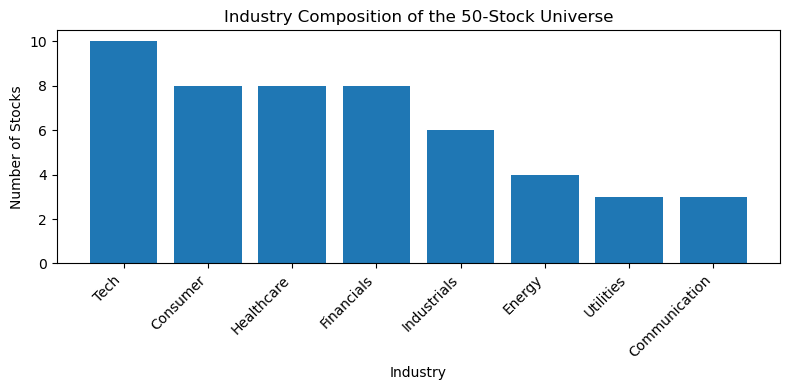

In [33]:
#2 Investment Universe Overview
 
#2.1 Industry composition
industry_info = industry_map.set_index("ticker").loc[ret.columns]
industry_counts = (
    industry_info["industry"]
    .value_counts()
    .rename_axis("industry")
    .reset_index(name="n_stocks")
)

display(industry_counts)

plt.figure(figsize=(8, 4))
plt.bar(industry_counts["industry"], industry_counts["n_stocks"])
plt.title("Industry Composition of the 50-Stock Universe")
plt.xlabel("Industry")
plt.ylabel("Number of Stocks")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



In [35]:

#2.2 Stock-level return and volatility summary
# ------------------------------------------------------------

stock_summary = pd.DataFrame({
    "industry": industry_info["industry"],
    "ann_return": annualised_ret(ret, freq=12),
    "ann_volatility": annualised_vol(ret, freq=12),
    "sharpe_ratio": sharpe_ratio(ret, freq=12, rf=0.03)
})

stock_summary = stock_summary.reset_index().rename(columns={"index": "ticker"})

display(
    stock_summary
    .sort_values("sharpe_ratio", ascending=False)
    .head(10)
)

# Industry-level average return and volatility
industry_summary = (
    stock_summary
    .groupby("industry")[["ann_return", "ann_volatility", "sharpe_ratio"]]
    .mean()
    .sort_values("sharpe_ratio", ascending=False)
)

display(industry_summary)

,ticker,industry,ann_return,ann_volatility,sharpe_ratio
29,AVGO,Tech,0.419431,0.313921,1.184748
22,LLY,Healthcare,0.270540,0.235213,1.013961
7,NVDA,Tech,0.462490,0.451278,1.004713
35,COST,Consumer,0.208193,0.187737,0.948500
0,AAPL,Tech,0.265387,0.265752,0.911852
4,MSFT,Tech,0.211021,0.215772,0.860728
46,HD,Consumer,0.196046,0.212309,0.813115
15,SPGI,Financials,0.207866,0.232992,0.803609
28,AMZN,Consumer,0.247872,0.295797,0.797445
44,GOOGL,Communication,0.207334,0.253687,0.754671


,ann_return,ann_volatility,sharpe_ratio
industry,,,
Tech,0.217568,0.290231,0.693789
Consumer,0.159137,0.208936,0.671625
Healthcare,0.154293,0.214498,0.619373
Utilities,0.120739,0.166949,0.581489
Financials,0.139019,0.274599,0.514272
Industrials,0.130985,0.274606,0.484241
Communication,0.123788,0.233643,0.470573
Energy,0.061928,0.293519,0.266883


average_correlation    0.307746
minimum_correlation   -0.070488
maximum_correlation    0.864176
dtype: float64

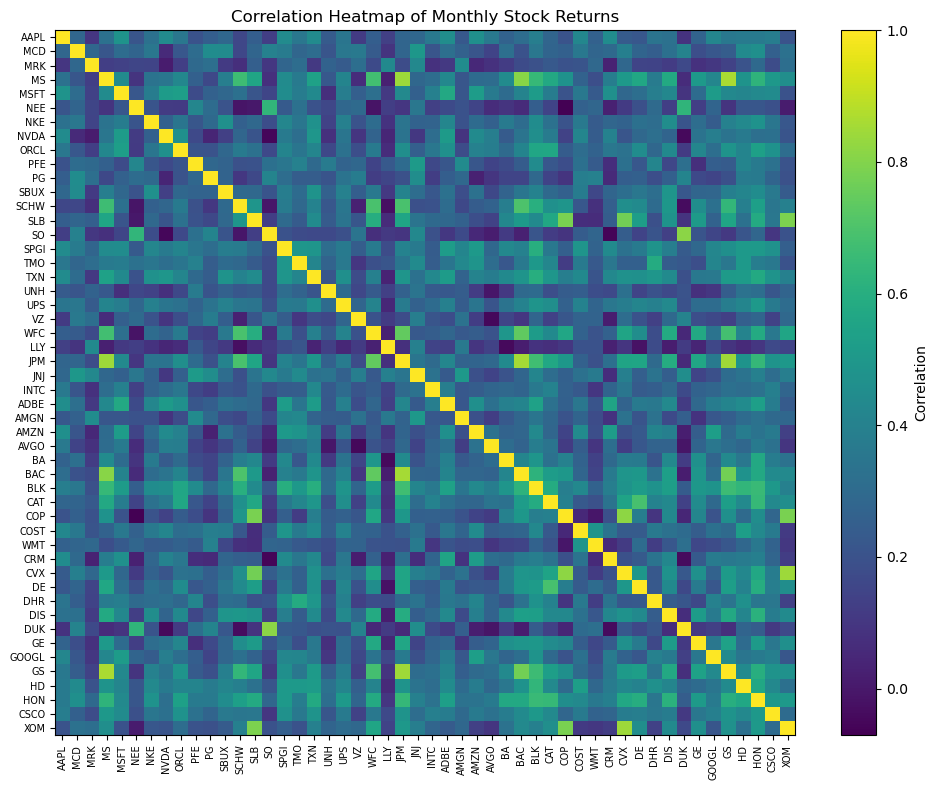

In [36]:
# 2.3 Correlation structure

corr_matrix = ret.corr()

corr_summary = pd.Series({
    "average_correlation": corr_matrix.where(~np.eye(corr_matrix.shape[0], dtype=bool)).stack().mean(),
    "minimum_correlation": corr_matrix.where(~np.eye(corr_matrix.shape[0], dtype=bool)).stack().min(),
    "maximum_correlation": corr_matrix.where(~np.eye(corr_matrix.shape[0], dtype=bool)).stack().max()
})

display(corr_summary)

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.title("Correlation Heatmap of Monthly Stock Returns")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90, fontsize=7)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index, fontsize=7)
plt.tight_layout()
plt.show()

In [ ]:
# 2.4 & 2.5 loading package for PCA and clustering
%pip install scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 2.1 MB/s eta 0:00:04
   ------ --------------------------------- 1.3/8.1 MB 3.4 MB/s eta 0:00:03
   ------------------- -------------------- 3.9/8.1 MB 6.7 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.1 MB 10.3 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 10.2 MB/s  0:00:01

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scik

In [ ]:
#  Data Structure Understanding: Clustering 

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Match return data with industry mapping
industry_map = industry_map.copy()
industry_map["ticker"] = industry_map["ticker"].astype(str)

common_tickers = [ticker for ticker in ret.columns if ticker in set(industry_map["ticker"])]
ret_used = ret[common_tickers].copy()

industry_used = (
    industry_map
    .set_index("ticker")
    .loc[common_tickers, "industry"]
)

# Standardise each stock return series before clustering and PCA
ret_scaled = pd.DataFrame(
    StandardScaler().fit_transform(ret_used),
    index=ret_used.index,
    columns=ret_used.columns
)

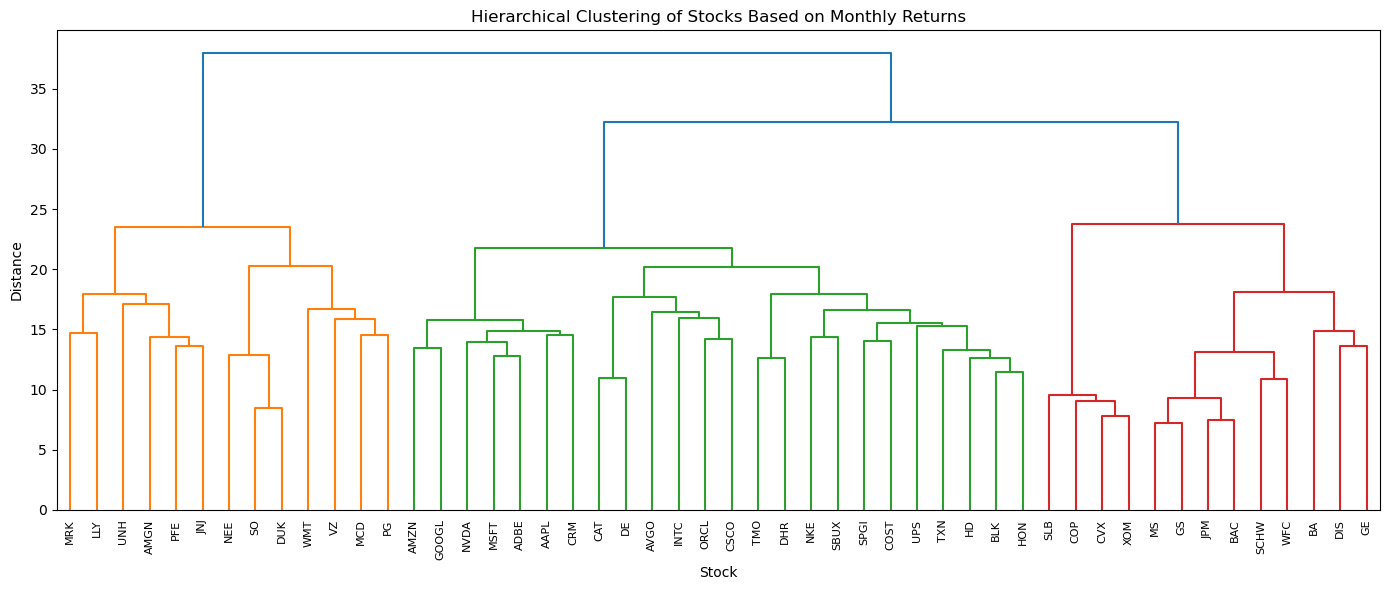

industry,Communication,Consumer,Energy,Financials,Healthcare,Industrials,Tech,Utilities
cluster,,,,,,,,
1,0,0,0,0,6,0,0,0
2,0,0,0,0,0,0,0,3
3,1,3,0,0,0,0,0,0
4,1,1,0,0,0,0,5,0
5,0,0,0,0,0,2,4,0
6,0,4,0,2,2,2,1,0
7,0,0,4,0,0,0,0,0
8,1,0,0,6,0,2,0,0


In [ ]:

#  Hierarchical clustering of stocks

# Cluster stocks based on their full monthly return history
X_cluster = ret_scaled.T

Z = linkage(X_cluster, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(
    Z,
    labels=X_cluster.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=8
)
plt.title("Hierarchical Clustering of Stocks Based on Monthly Returns")
plt.xlabel("Stock")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# Create flat cluster labels
n_clusters = industry_used.nunique()

cluster_result = pd.DataFrame({
    "ticker": X_cluster.index,
    "industry": industry_used.values,
    "cluster": fcluster(Z, t=n_clusters, criterion="maxclust")
})


display(pd.crosstab(cluster_result["cluster"], cluster_result["industry"]))

The dendrogram shows the hierarchical clustering of stocks based on their full monthly return histories. Each stock is treated as one observation, with its monthly returns over the sample period used as features. Stocks that merge at a lower distance have more similar return patterns.

The clustering result suggests that stocks from similar industries or with similar risk exposures tend to group together. For example, several energy stocks and healthcare-related stocks appear close to each other in the tree. This indicates that the return data contains an industry-related structure, which is important for portfolio construction because holding many stocks does not necessarily imply full diversification if their returns are highly correlated.

In [ ]:

# PCA


# Match tickers between return data and industry table
common_tickers = [ticker for ticker in ret.columns if ticker in set(industry_map["ticker"])]

ret_pca = ret[common_tickers].copy()

# Standardise each stock return series
ret_scaled = (ret_pca - ret_pca.mean()) / ret_pca.std(ddof=1)

# PCA using SVD
X = ret_scaled.values
U, S, Vt = np.linalg.svd(X, full_matrices=False)

n_components = 10

# PCA scores: monthly time-series of principal components
pca_scores = pd.DataFrame(
    U[:, :n_components] * S[:n_components],
    index=ret_scaled.index,
    columns=[f"PC{i}" for i in range(1, n_components + 1)]
)

# PCA loadings: stock contribution to each PC
pca_loadings = pd.DataFrame(
    Vt[:n_components, :].T,
    index=ret_scaled.columns,
    columns=[f"PC{i}" for i in range(1, n_components + 1)]
)

# Explained variance
explained_variance_ratio = (S ** 2) / np.sum(S ** 2)

pca_summary = pd.DataFrame({
    "PC": [f"PC{i}" for i in range(1, n_components + 1)],
    "explained_variance_ratio": explained_variance_ratio[:n_components],
    "cumulative_explained_variance": np.cumsum(explained_variance_ratio[:n_components])
})

display(pca_summary)
display(pca_loadings.head())
display(pca_scores.head())

,PC,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.339534,0.339534
1,PC2,0.085060,0.424594
2,PC3,0.066780,0.491374
3,PC4,0.037712,0.529086
4,PC5,0.031525,0.560611
5,PC6,0.027837,0.588448
6,PC7,0.026739,0.615187
7,PC8,0.023058,0.638245
8,PC9,0.020913,0.659158
9,PC10,0.019335,0.678493


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
AAPL,0.132405,-0.060368,0.191413,-0.034195,0.206466,-0.005418,0.000526,-0.086496,0.166427,-0.202313
MCD,0.124209,-0.175045,-0.094377,0.127417,0.147971,-0.173915,-0.189079,-0.005887,-0.199844,-0.000573
MRK,0.078845,-0.152537,-0.167594,-0.343783,0.062502,-0.221740,0.189423,0.023981,-0.106163,0.168685
MS,0.186697,0.174076,-0.015258,0.004137,-0.243776,0.024785,0.025642,-0.063029,0.010116,-0.091836
MSFT,0.151959,-0.022911,0.208413,0.038320,0.135728,0.044070,0.138025,-0.113993,0.039058,0.038444


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
Date,,,,,,,,,,
2010-01-01,-5.248744,0.666848,-1.844040,-1.127939,-1.191342,-2.036751,-0.432715,0.438117,-0.587616,-0.474205
2010-02-01,1.989300,1.028473,0.880146,1.075530,-0.194745,-0.757815,-0.260978,2.244877,-0.389257,-1.224401
2010-03-01,4.314525,0.343258,0.251806,0.592598,1.074932,0.030105,0.506565,-1.146569,-1.378206,0.358667
2010-04-01,0.236799,0.564545,-0.498376,1.981521,1.511722,1.346898,-2.475794,0.894542,-1.004018,0.194149
2010-05-01,-8.836073,1.057444,0.955022,0.721257,-0.344833,-0.743724,-1.044658,0.753871,-0.327546,-0.812631


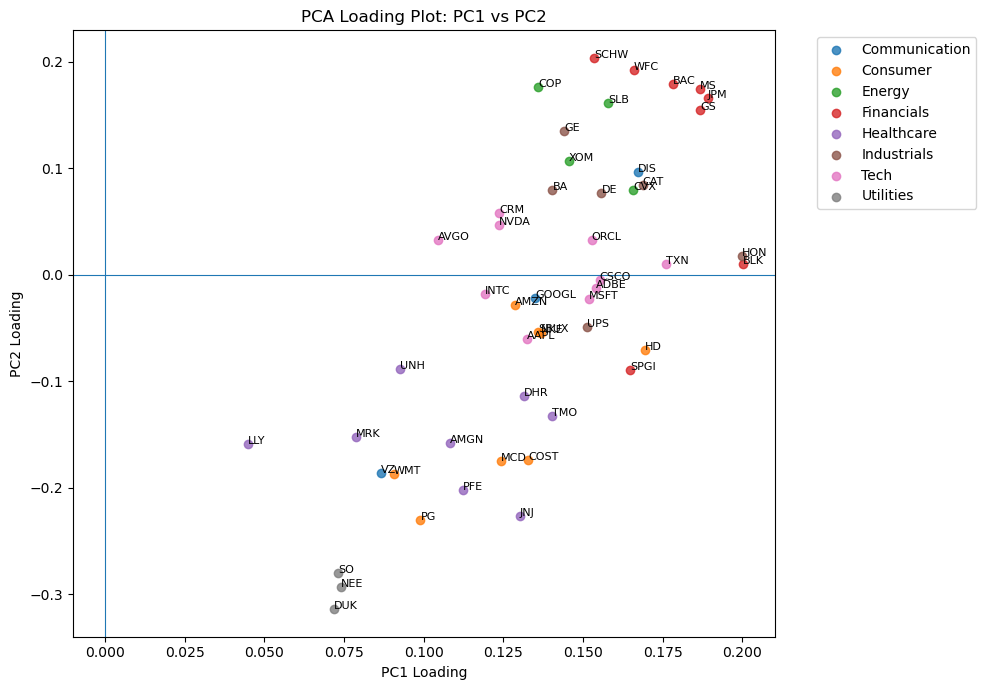

In [ ]:
# 2.3 PCA Loading Plot: PC1 vs PC2


pca_plot_df = (
    pca_loadings[["PC1", "PC2"]]
    .reset_index()
    .rename(columns={"index": "ticker"})
    .merge(industry_map, on="ticker", how="left")
)

plt.figure(figsize=(10, 7))

for industry, group in pca_plot_df.groupby("industry"):
    plt.scatter(group["PC1"], group["PC2"], label=industry, alpha=0.8)

for _, row in pca_plot_df.iterrows():
    plt.text(row["PC1"], row["PC2"], row["ticker"], fontsize=8)

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.title("PCA Loading Plot: PC1 vs PC2")
plt.xlabel("PC1 Loading")
plt.ylabel("PC2 Loading")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

PCA shows that the 50-stock universe has a clear common return structure. PC1 explains about 34% of total variation, suggesting a strong market-wide component, while the first ten PCs explain about 68% in total. The PC1-PC2 loading plot also shows some industry-related separation, with financials and energy positioned differently from defensive sectors such as utilities and healthcare. This suggests that portfolio risk is affected by both broad market movements and sector-related exposures, not only by individual stock risk.